# 02 — Background flow and radial-profile departures

**Question:** How are ESP estimates biased when velocity observations contain a background current, shear, or a non-Gaussian vortex profile?

Three small, **noise-free** experiments vary one factor at a time. Sampling, core windows and initial location settings are fixed. Each condition is fitted once: there are no Monte Carlo intervals here. This measures limitations of a vortex-only fit; it does not introduce background subtraction or a joint background estimator.

Run from `UNSW-PhD/esp` or the repository root. Restart the kernel after pulling helper updates. All new functions live here; `ESP_zonodo` remains unchanged.

In [1]:
# Editable controls — SAVE_OUTPUTS controls result files, not Jupyter autosaving.
from pathlib import Path
SAVE_OUTPUTS = False
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")

RC_M = 85_000.0
OMEGA = -6.9e-5
ALPHA = 1.527525
ANGLE_DEG = 35.0
CORE_RADIUS_M = 30_000.0
RC_LIMIT_M = 100_000.0             # same post-fit limit as notebook 1
USE_LOCAL_SOLO = True              # labelled explicitly in all tables/plots
SOLO_CENTRE_GUESS_M = 10_000.0     # not read from the synthetic truth
SOLO_SEARCH_HALF_WIDTH_M = 60_000.0

ORIENTATIONS_DEG = [0.0, 90.0]      # CCW from east; signed strengths test both directions
CURRENT_STRENGTHS = [-0.4, -0.2, -0.1, 0.0, 0.1, 0.2, 0.4]  # Ubackground / Vref
SHEAR_STRENGTHS = [-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0] # S Rc / Vref
TAIL_POWERS = [float("inf"), 8.0, 4.0, 2.0]                # infinity = Gaussian
GEOMETRY_SEED = 1729

In [2]:
import sys, json, hashlib
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / "departure_helpers.py").is_file():
    HERE = HERE / "esp"
if not (HERE / "departure_helpers.py").is_file():
    raise FileNotFoundError("Run from UNSW-PhD or UNSW-PhD/esp.")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
import validation_helpers as vh
import departure_helpers as dh

esp, backend_info = vh.load_backend(ESP_ROOT)
cases = vh.make_cases(rc=RC_M, omega=OMEGA, alpha=ALPHA, angle_deg=ANGLE_DEG, seed=GEOMETRY_SEED)
fit_settings = dict(radius=CORE_RADIUS_M, rc_limit=RC_LIMIT_M, solo_local=USE_LOCAL_SOLO,
    centre_guess=SOLO_CENTRE_GUESS_M, search_half_width=SOLO_SEARCH_HALF_WIDTH_M)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR = HERE / "results" / "02_background_and_model_departure" / RUN_ID
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

def show_results(results, name):
    fig = dh.plot_test(results)
    if SAVE_OUTPUTS:
        results.to_csv(OUTPUT_DIR / f"{name}_attempts.csv", index=False)
        for ext in ("png", "pdf"):
            fig.savefig(OUTPUT_DIR / f"{name}.{ext}", dpi=200)
    plt.show()
    columns = ["method", "strength", "angle_deg_background", "tail_power", "status",
        "centre_error_km", "peak_radius_error_pct", "vorticity_error_pct",
        "alpha_error_pct", "angle_error_deg", "eddy_velocity_rmse_ms", "total_velocity_rmse_ms"]
    display(results.reindex(columns=columns).round(3))

settings = dict(Rc_m=RC_M, Omega=OMEGA, alpha=ALPHA, angle_deg=ANGLE_DEG,
    fit=fit_settings, orientations_deg=ORIENTATIONS_DEG, current_strengths=CURRENT_STRENGTHS,
    shear_strengths=SHEAR_STRENGTHS, tail_powers=["Gaussian" if np.isinf(p) else p for p in TAIL_POWERS],
    geometry_seed=GEOMETRY_SEED, save_outputs=SAVE_OUTPUTS,
    transect_spacing_m=2500., outer_extent_Rc=2., evaluation_grid_n=45)
provenance = dict(run_id=RUN_ID, backend=backend_info, settings=settings,
    local_files_sha256={name: hashlib.sha256((HERE/name).read_bytes()).hexdigest() for name in
        ["validation_helpers.py", "local_estimators.py", "departure_helpers.py", "02_background_and_model_departure.ipynb"]})
if SAVE_OUTPUTS:
    (OUTPUT_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2))
print("ESP:", backend_info["path"])
print("SHA256:", backend_info["sha256"])
print("Output:", OUTPUT_DIR if SAVE_OUTPUTS else "Display only; no result files written")

ESP: /home/z5297792/ESP_zonodo/functions.py
SHA256: 8e4b06fe4c144f7a70671ee913b6d27784f9cdb587e9b08a2469d82e51be6154
Output: Display only; no result files written


## Baseline and definitions

Reuse notebook 1's circular SOLO vortex and elliptical DOPPIO/LATTE vortex, with the same fixed sampling. SOLO uses the local initialisation variant by default; setting `USE_LOCAL_SOLO=False` selects the original. DOPPIO/LATTE retain the imported inner estimators. All fits use the local explicit-status outer function from notebook 1.

**Parameter target:** the known eddy component, even when background flow is present. A background shear has its own vorticity; its absorption into the eddy fit counts as contamination of the eddy estimate, not an error in the total-flow vorticity.

**Velocity check:** predict both components on a separate fixed grid within true effective radius 2 Rc, excluding observation locations. Report vector RMSE against (a) the eddy component and (b) total eddy-plus-background flow. Normalise by the Gaussian control's peak absolute normalised tangential speed, `Vref = |Omega| Rc / sqrt(2e)`. That reference stays fixed across all departures. This is noise-free reconstruction error on withheld locations, not observational cross-validation.

**Size:** compare the equal-area radius of the peak normalised tangential-speed contour. For a fitted Gaussian this is fitted Rc/√2. A non-Gaussian profile has no true Gaussian Rc, so no Gaussian-Rc error is reported. Angles are axial, and SOLO's imposed circular shape is not scored.

In [3]:
baseline = pd.DataFrame([dh.run_case(esp, c, kind="current", **fit_settings) for c in cases.values()])
display(baseline.reindex(columns=["method", "status", "centre_error_km", "peak_radius_error_pct",
    "vorticity_error_pct", "eddy_velocity_rmse_ms"]).round(4))
if not baseline.valid.all():
    raise RuntimeError("A zero-departure baseline failed; inspect backend/settings before proceeding.")
VREF = cases["SOLO"]["speed_ref"]
print(f"Vref = {VREF:.3f} m/s; true peak radius = {RC_M / np.sqrt(2) / 1000:.2f} km")
display(pd.DataFrame({"current_fraction": CURRENT_STRENGTHS,
    "signed_current_m_s": np.asarray(CURRENT_STRENGTHS)*VREF}))
display(pd.DataFrame({"shear_fraction": SHEAR_STRENGTHS,
    "signed_shear_s_inv": np.asarray(SHEAR_STRENGTHS)*VREF/RC_M}))
if SAVE_OUTPUTS:
    baseline.to_csv(OUTPUT_DIR / "baseline.csv", index=False)

,method,status,centre_error_km,peak_radius_error_pct,vorticity_error_pct,eddy_velocity_rmse_ms
0,SOLO local,ok,0.0235,0.0123,-0.0258,0.0006
1,DOPPIO,ok,0.0987,0.0368,-0.0580,0.0025
2,LATTE,ok,0.1037,-0.0980,0.0116,0.0288


Vref = 2.515 m/s; true peak radius = 60.10 km


,current_fraction,signed_current_m_s
0,-0.4,-1.006157
1,-0.2,-0.503079
2,-0.1,-0.251539
3,0.0,0.000000
4,0.1,0.251539
5,0.2,0.503079
6,0.4,1.006157


,shear_fraction,signed_shear_s_inv
0,-1.00,-0.000030
1,-0.50,-0.000015
2,-0.25,-0.000007
3,0.00,0.000000
4,0.25,0.000007
5,0.50,0.000015
6,1.00,0.000030


## A. Uniform background current

Add a spatially constant vector. Orientation 0° is eastward and 90° northward; negative strengths reverse direction. In the SOLO frame these are along- and across-track currents. No background is removed before fitting.

In a purely linear core, `u = A(x-c) + b`: background `b` and centre `c` enter through the same intercept. This experiment measures the resulting bias; fitting extra free core-background parameters alone would not resolve that ambiguity.

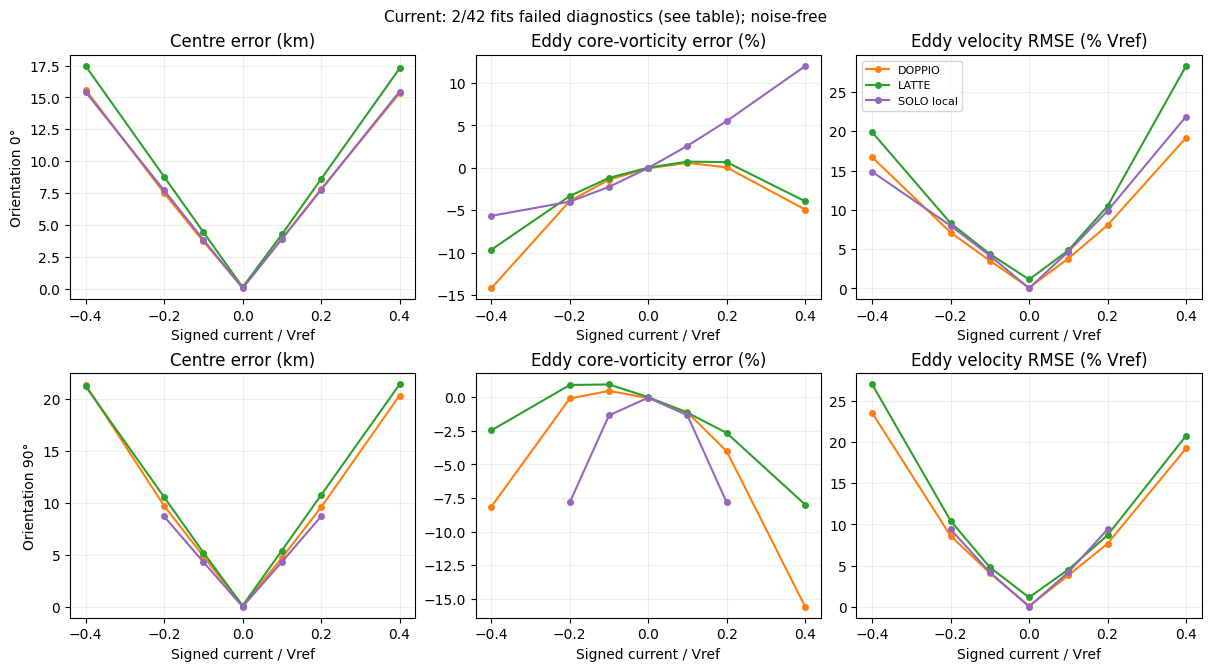

,method,strength,angle_deg_background,tail_power,status,centre_error_km,peak_radius_error_pct,vorticity_error_pct,alpha_error_pct,angle_error_deg,eddy_velocity_rmse_ms,total_velocity_rmse_ms
0,SOLO local,-0.4,0.0,inf,ok,15.417,-0.673,-5.662,NaN,NaN,0.373,1.057
1,SOLO local,-0.2,0.0,inf,ok,7.697,-0.932,-3.992,NaN,NaN,0.201,0.534
2,SOLO local,-0.1,0.0,inf,ok,3.837,-0.618,-2.251,NaN,NaN,0.105,0.269
3,SOLO local,0.0,0.0,inf,ok,0.024,0.012,-0.026,NaN,NaN,0.001,0.001
4,SOLO local,0.1,0.0,inf,ok,3.884,0.960,2.588,NaN,NaN,0.118,0.273
5,SOLO local,0.2,0.0,inf,ok,7.744,2.216,5.505,NaN,NaN,0.248,0.550
6,SOLO local,0.4,0.0,inf,ok,15.464,5.565,11.979,NaN,NaN,0.550,1.117
7,SOLO local,-0.4,90.0,inf,outer_radius_limit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,SOLO local,-0.2,90.0,inf,ok,8.705,5.681,-7.830,NaN,NaN,0.237,0.542
9,SOLO local,-0.1,90.0,inf,ok,4.324,0.726,-1.344,NaN,NaN,0.105,0.267


In [4]:
current_results = pd.DataFrame([
    dh.run_case(esp, case, kind="current", strength=strength, angle_deg=angle, **fit_settings)
    for case in cases.values() for angle in ORIENTATIONS_DEG for strength in CURRENT_STRENGTHS
])
show_results(current_results, "uniform_current")

## B. Linear background shear

In axes rotated by the stated angle, add `u' = S y'`, `v' = 0`, with coordinates relative to the fixed synthetic centre. This is divergence-free, with relative vorticity `-S`. At 0° it is `u = S y`; at 90° it is `v = -S x`. Signed strengths test both signs of shear. Rotation changes how the shear aligns with the eddy and sampling; it does not change its curl.

This is one specified simple-shear family, not a survey of every background gradient. Keep the eddy component, sampling and fitting windows unchanged.

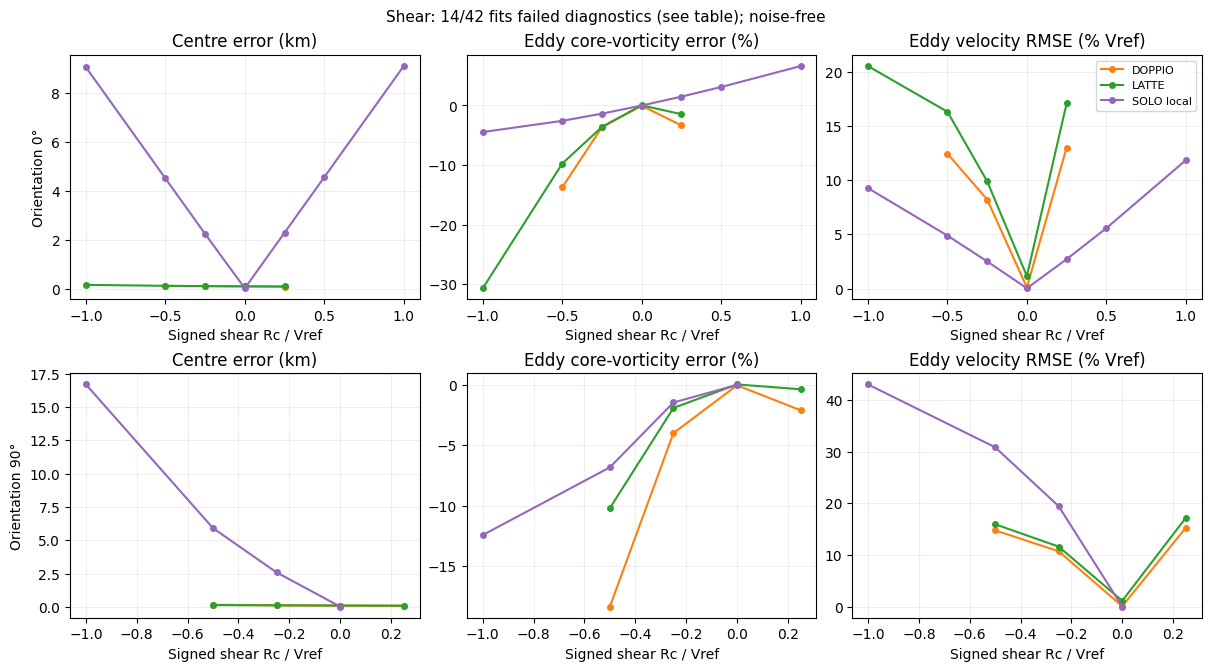

,method,strength,angle_deg_background,tail_power,status,centre_error_km,peak_radius_error_pct,vorticity_error_pct,alpha_error_pct,angle_error_deg,eddy_velocity_rmse_ms,total_velocity_rmse_ms
0,SOLO local,-1.00,0.0,inf,ok,9.059,-0.970,-4.473,NaN,NaN,0.233,2.477
1,SOLO local,-0.50,0.0,inf,ok,4.518,-0.696,-2.596,NaN,NaN,0.123,1.233
2,SOLO local,-0.25,0.0,inf,ok,2.247,-0.397,-1.388,NaN,NaN,0.063,0.615
3,SOLO local,0.00,0.0,inf,ok,0.024,0.012,-0.026,NaN,NaN,0.001,0.001
4,SOLO local,0.25,0.0,inf,ok,2.294,0.532,1.470,NaN,NaN,0.068,0.612
5,SOLO local,0.50,0.0,inf,ok,4.565,1.160,3.083,NaN,NaN,0.140,1.221
6,SOLO local,1.00,0.0,inf,ok,9.106,2.729,6.593,NaN,NaN,0.298,2.431
7,SOLO local,-1.00,90.0,inf,ok,16.682,-34.834,-12.435,NaN,NaN,1.081,2.182
8,SOLO local,-0.50,90.0,inf,ok,5.906,-23.276,-6.842,NaN,NaN,0.776,1.052
9,SOLO local,-0.25,90.0,inf,ok,2.588,-14.435,-1.481,NaN,NaN,0.489,0.522


In [5]:
shear_results = pd.DataFrame([
    dh.run_case(esp, case, kind="shear", strength=strength, angle_deg=angle, **fit_settings)
    for case in cases.values() for angle in ORIENTATIONS_DEG for strength in SHEAR_STRENGTHS
])
show_results(shear_results, "linear_shear")

## C. One non-Gaussian radial-profile family

Keep elliptical geometry and replace only the Gaussian envelope:

\[
\mathbf u=\Omega JQ\mathbf r\,g_p(s),\qquad
s=\rho^2/R_c^2,\qquad
 g_p(s)=\left(1+\frac{2s}{2p-1}\right)^{-p},\quad p>1.
\]

The Gaussian is the limit `p → infinity`. Finite p gives a heavier tail. All profiles have `g(0)=1`, so the same core vorticity, and peak normalised speed at `rho=Rc/√2`. Peak **speed** is allowed to vary; matching centre gradient, peak location and peak speed simultaneously would require additional choices.

This family is nondivergent because the envelope depends only on elliptical radius and velocity is tangent to its contours. It tests radial misspecification only: asymmetric vortices and radial flow remain outside this notebook.

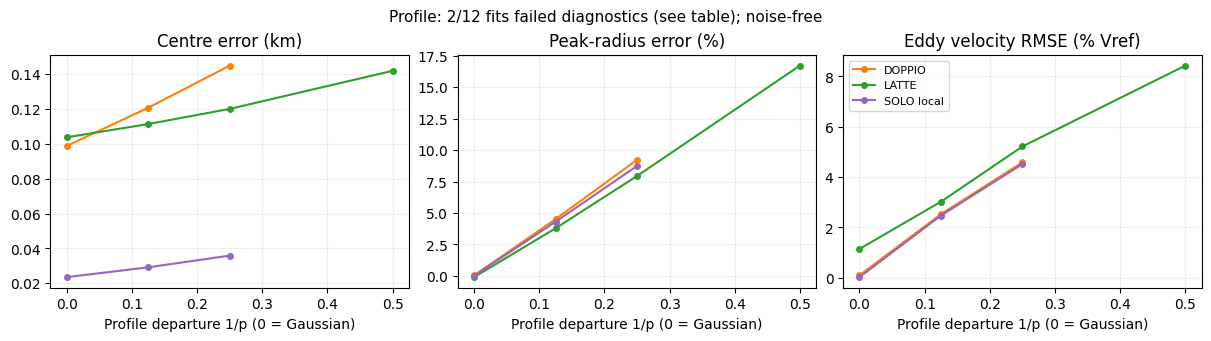

,method,strength,angle_deg_background,tail_power,status,centre_error_km,peak_radius_error_pct,vorticity_error_pct,alpha_error_pct,angle_error_deg,eddy_velocity_rmse_ms,total_velocity_rmse_ms
0,SOLO local,0.0,0.0,inf,ok,0.024,0.012,-0.026,NaN,NaN,0.001,0.001
1,SOLO local,0.0,0.0,8.0,ok,0.029,4.303,-4.996,NaN,NaN,0.062,0.062
2,SOLO local,0.0,0.0,4.0,ok,0.036,8.742,-9.790,NaN,NaN,0.114,0.114
3,SOLO local,0.0,0.0,2.0,outer_radius_limit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DOPPIO,0.0,0.0,inf,ok,0.099,0.037,-0.058,0.123,0.023,0.002,0.002
5,DOPPIO,0.0,0.0,8.0,ok,0.121,4.507,-5.338,0.146,0.034,0.064,0.064
6,DOPPIO,0.0,0.0,4.0,ok,0.145,9.227,-10.491,0.164,0.057,0.115,0.115
7,DOPPIO,0.0,0.0,2.0,outer_radius_limit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,LATTE,0.0,0.0,inf,ok,0.104,-0.098,0.012,-0.942,1.332,0.029,0.029
9,LATTE,0.0,0.0,8.0,ok,0.111,3.785,-3.976,-0.987,1.392,0.076,0.076


In [6]:
profile_results = pd.DataFrame([
    dh.run_case(esp, case, kind="profile", tail_power=p, **fit_settings)
    for case in cases.values() for p in TAIL_POWERS
])
show_results(profile_results, "radial_profile")

## Failure audit and interpretation

No accuracy cutoff removes large finite errors. Invalid fits appear as gaps in plots and remain in the table. `outer_radius_limit` means the attempted Gaussian radius exceeded the retained 100 km limit; it does not by itself prove the vortex representation is unusable. Inspect the attempted Rc. These deterministic counts describe the tested conditions, not statistical failure probabilities.

Before writing the revision, identify: (1) the background strengths at which centre/geometry bias becomes appreciable; (2) whether small total-flow residuals conceal an incorrect eddy component; (3) whether peak radius remains useful under non-Gaussian profiles; and (4) numerical or radius-limit failures. Parameter biases include the zero-departure approximation bias, which is shown rather than subtracted. Sampling differs between methods, so avoid an unconditional ranking.

A concise paper addition can use the background-sensitivity figure and a short profile comparison; detailed tables can remain supplementary. No general robustness claim or background correction is established by this notebook alone.

In [7]:
results = pd.concat([current_results, shear_results, profile_results], ignore_index=True)
failures = results.loc[~results.valid]
if len(failures):
    display(failures.reindex(columns=["test", "method", "strength", "angle_deg_background",
        "tail_power", "status", "Rc_m", "outer_message", "exception"]))
else:
    print("All tested conditions passed numerical/physical diagnostics.")
display(results.groupby(["test", "method", "status"]).size().rename("conditions").reset_index())
if SAVE_OUTPUTS:
    results.to_csv(OUTPUT_DIR / "all_attempts.csv", index=False)
print(f"Completed {len(results)} deterministic conditions.")
print("Saved:", OUTPUT_DIR) if SAVE_OUTPUTS else print("Display-only run; no files saved.")

,test,method,strength,angle_deg_background,tail_power,status,Rc_m,outer_message,exception
7,current,SOLO local,-0.40,90.0,inf,outer_radius_limit,125897.320040,NaN,NaN
13,current,SOLO local,0.40,90.0,inf,outer_radius_limit,124657.184614,NaN,NaN
53,shear,SOLO local,0.25,90.0,inf,outer_radius_limit,106142.766142,NaN,NaN
54,shear,SOLO local,0.50,90.0,inf,outer_radius_limit,126926.451382,NaN,NaN
55,shear,SOLO local,1.00,90.0,inf,outer_radius_limit,162759.038934,NaN,NaN
56,shear,DOPPIO,-1.00,0.0,inf,outer_radius_limit,101085.500693,NaN,NaN
61,shear,DOPPIO,0.50,0.0,inf,outer_radius_limit,104805.458213,NaN,NaN
62,shear,DOPPIO,1.00,0.0,inf,outer_radius_limit,158508.685241,NaN,NaN
63,shear,DOPPIO,-1.00,90.0,inf,outer_radius_limit,112381.859869,NaN,NaN
68,shear,DOPPIO,0.50,90.0,inf,outer_radius_limit,102973.993928,NaN,NaN


,test,method,status,conditions
0,current,DOPPIO,ok,14
1,current,LATTE,ok,14
2,current,SOLO local,ok,12
3,current,SOLO local,outer_radius_limit,2
4,profile,DOPPIO,ok,3
5,profile,DOPPIO,outer_radius_limit,1
6,profile,LATTE,ok,4
7,profile,SOLO local,ok,3
8,profile,SOLO local,outer_radius_limit,1
9,shear,DOPPIO,ok,8


Completed 96 deterministic conditions.
Display-only run; no files saved.
